In [2]:
import os
os.environ.pop("TF_USE_LEGACY_KERAS", None)


import librosa
%matplotlib inline
import matplotlib.pyplot as plt
import librosa.display
from IPython.display import Audio
import numpy as np
import tensorflow as tf
from matplotlib.pyplot import specgram
import pandas as pd
from sklearn.metrics import confusion_matrix
import IPython.display as ipd
import sys

data = pd.read_csv('../../data/featureEMOVO.csv')

In [ ]:
import numpy as np
import random

np.random.seed(42)
random.seed(42)

In [3]:
data

,0,1,2,3,4,5,6,7,8,9,...,186,187,188,189,190,191,192,gender,labels,speaker
0,-370.303223,58.331867,-7.632109,15.654898,3.273010,0.692397,-8.063744,5.894156,-5.199350,12.546567,...,34.036367,-0.028319,0.053574,-0.043633,-0.009186,0.019449,-0.007346,1,1,1
1,-374.553833,47.796314,1.653561,20.256063,-6.800525,0.783256,-4.250007,7.473405,-15.591282,14.261038,...,34.229551,0.023288,0.050375,-0.021473,0.040849,0.002533,0.025532,1,1,1
2,-386.473145,75.599594,-15.072874,6.823948,-1.835993,-4.165404,-10.107768,7.045069,-17.148949,11.959360,...,34.157690,0.013844,0.000709,-0.032024,-0.007825,0.018322,0.016368,1,1,1
3,-362.502167,89.977379,-15.514508,5.774208,4.361949,12.591103,-0.374380,-0.392911,-4.743288,15.702434,...,32.441757,0.002924,0.020344,-0.057423,0.041032,-0.014291,-0.002126,1,1,1
4,-412.010406,83.760246,-2.188665,18.547068,0.581788,10.956905,3.381726,3.320800,-9.278383,11.129302,...,33.286765,0.001819,0.007893,-0.003650,0.014794,0.000603,0.001663,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
583,-428.723602,127.801125,15.011064,26.158209,-22.814543,10.531158,8.283092,-1.291359,-13.442948,11.084978,...,33.880198,-0.017768,0.023105,0.130201,0.076282,-0.008200,-0.029686,2,7,6
584,-433.270050,98.356888,24.055376,35.478432,-30.932493,11.173256,12.042026,-1.199043,-12.588658,7.034428,...,34.613071,-0.027987,-0.025462,-0.003617,0.090180,-0.020973,0.000550,2,7,6
585,-458.537323,104.085503,15.052121,37.028015,-10.172383,10.071804,2.412206,-3.682174,-7.252892,11.958858,...,34.431134,0.087554,0.064611,0.170886,-0.068005,0.058233,-0.019411,2,7,6
586,-523.336914,88.056267,18.831060,43.098541,-8.197763,15.856596,4.796964,4.109037,-4.488383,12.122023,...,33.439551,0.031808,-0.014211,0.000701,-0.059435,0.022520,0.021469,2,7,6


In [4]:
df = data

In [5]:
df.shape

(588, 196)

In [6]:
df

,0,1,2,3,4,5,6,7,8,9,...,186,187,188,189,190,191,192,gender,labels,speaker
0,-370.303223,58.331867,-7.632109,15.654898,3.273010,0.692397,-8.063744,5.894156,-5.199350,12.546567,...,34.036367,-0.028319,0.053574,-0.043633,-0.009186,0.019449,-0.007346,1,1,1
1,-374.553833,47.796314,1.653561,20.256063,-6.800525,0.783256,-4.250007,7.473405,-15.591282,14.261038,...,34.229551,0.023288,0.050375,-0.021473,0.040849,0.002533,0.025532,1,1,1
2,-386.473145,75.599594,-15.072874,6.823948,-1.835993,-4.165404,-10.107768,7.045069,-17.148949,11.959360,...,34.157690,0.013844,0.000709,-0.032024,-0.007825,0.018322,0.016368,1,1,1
3,-362.502167,89.977379,-15.514508,5.774208,4.361949,12.591103,-0.374380,-0.392911,-4.743288,15.702434,...,32.441757,0.002924,0.020344,-0.057423,0.041032,-0.014291,-0.002126,1,1,1
4,-412.010406,83.760246,-2.188665,18.547068,0.581788,10.956905,3.381726,3.320800,-9.278383,11.129302,...,33.286765,0.001819,0.007893,-0.003650,0.014794,0.000603,0.001663,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
583,-428.723602,127.801125,15.011064,26.158209,-22.814543,10.531158,8.283092,-1.291359,-13.442948,11.084978,...,33.880198,-0.017768,0.023105,0.130201,0.076282,-0.008200,-0.029686,2,7,6
584,-433.270050,98.356888,24.055376,35.478432,-30.932493,11.173256,12.042026,-1.199043,-12.588658,7.034428,...,34.613071,-0.027987,-0.025462,-0.003617,0.090180,-0.020973,0.000550,2,7,6
585,-458.537323,104.085503,15.052121,37.028015,-10.172383,10.071804,2.412206,-3.682174,-7.252892,11.958858,...,34.431134,0.087554,0.064611,0.170886,-0.068005,0.058233,-0.019411,2,7,6
586,-523.336914,88.056267,18.831060,43.098541,-8.197763,15.856596,4.796964,4.109037,-4.488383,12.122023,...,33.439551,0.031808,-0.014211,0.000701,-0.059435,0.022520,0.021469,2,7,6


In [7]:
X = df.iloc[:, :-3].copy()
y = df.iloc[:,-2].copy()

In [8]:
X

,0,1,2,3,4,5,6,7,8,9,...,183,184,185,186,187,188,189,190,191,192
0,-370.303223,58.331867,-7.632109,15.654898,3.273010,0.692397,-8.063744,5.894156,-5.199350,12.546567,...,17.334037,17.539159,17.562779,34.036367,-0.028319,0.053574,-0.043633,-0.009186,0.019449,-0.007346
1,-374.553833,47.796314,1.653561,20.256063,-6.800525,0.783256,-4.250007,7.473405,-15.591282,14.261038,...,16.263369,17.699334,19.162629,34.229551,0.023288,0.050375,-0.021473,0.040849,0.002533,0.025532
2,-386.473145,75.599594,-15.072874,6.823948,-1.835993,-4.165404,-10.107768,7.045069,-17.148949,11.959360,...,18.860587,18.714656,19.843059,34.157690,0.013844,0.000709,-0.032024,-0.007825,0.018322,0.016368
3,-362.502167,89.977379,-15.514508,5.774208,4.361949,12.591103,-0.374380,-0.392911,-4.743288,15.702434,...,15.868680,18.698590,19.053175,32.441757,0.002924,0.020344,-0.057423,0.041032,-0.014291,-0.002126
4,-412.010406,83.760246,-2.188665,18.547068,0.581788,10.956905,3.381726,3.320800,-9.278383,11.129302,...,16.198743,17.339091,18.793145,33.286765,0.001819,0.007893,-0.003650,0.014794,0.000603,0.001663
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
583,-428.723602,127.801125,15.011064,26.158209,-22.814543,10.531158,8.283092,-1.291359,-13.442948,11.084978,...,16.535757,15.881800,18.443654,33.880198,-0.017768,0.023105,0.130201,0.076282,-0.008200,-0.029686
584,-433.270050,98.356888,24.055376,35.478432,-30.932493,11.173256,12.042026,-1.199043,-12.588658,7.034428,...,16.113687,16.514813,18.799787,34.613071,-0.027987,-0.025462,-0.003617,0.090180,-0.020973,0.000550
585,-458.537323,104.085503,15.052121,37.028015,-10.172383,10.071804,2.412206,-3.682174,-7.252892,11.958858,...,14.285399,16.010688,18.472471,34.431134,0.087554,0.064611,0.170886,-0.068005,0.058233,-0.019411
586,-523.336914,88.056267,18.831060,43.098541,-8.197763,15.856596,4.796964,4.109037,-4.488383,12.122023,...,14.503504,15.854289,17.343597,33.439551,0.031808,-0.014211,0.000701,-0.059435,0.022520,0.021469


In [9]:
y

0      1
1      1
2      1
3      1
4      1
      ..
583    7
584    7
585    7
586    7
587    7
Name: labels, Length: 588, dtype: int64

In [10]:
X.shape, y.shape

((588, 193), (588,))

In [11]:
from keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
lb = LabelEncoder()
y1 = to_categorical(lb.fit_transform(y))

In [12]:
y1

array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], shape=(588, 7))

In [13]:
X.shape, y1.shape

((588, 193), (588, 7))

In [14]:
X2=X.copy().to_numpy()
y2=y.copy().to_numpy()

In [15]:
X2.shape, y2.shape

((588, 193), (588,))

In [16]:
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from matplotlib.pyplot import specgram
import keras

from keras.preprocessing import sequence
from keras.models import Sequential
from keras.layers import Dense, Embedding, Activation
from keras.layers import LSTM

from keras.utils import to_categorical
from keras.layers import Input, Flatten, Dropout#, Activation
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
from keras.models import Model
from keras.callbacks import ModelCheckpoint
from sklearn.metrics import confusion_matrix
from keras.layers import BatchNormalization

def model1(input_shape1):
    model = Sequential()

    model.add(Conv1D(256, 5,padding='same',
                     input_shape=(input_shape1,1)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))


    model.add(Conv1D(256, 5,padding='same'))
    model.add(Activation('relu'))
    model.add(Dropout(0.1))

    model.add(BatchNormalization())

    model.add(MaxPooling1D(pool_size=(8)))
    model.add(Conv1D(256, 5,padding='same',))

    model.add(Activation('relu'))

    model.add(Conv1D(128, 5,padding='same',))
    model.add(Activation('relu'))
    model.add(Conv1D(128, 5,padding='same',))
    model.add(BatchNormalization())

    model.add(Activation('relu'))
    model.add(Dropout(0.2))

    model.add(Flatten())
    model.add(Dropout(0.2))
    model.add(Dense(7))
    model.add(BatchNormalization())
    model.add(Activation('softmax'))

    return model

In [17]:
import random, numpy as np
from keras import optimizers
kfold=5
def create_index(kfold, size):
    a = []
    for i in range(size):
        a.append(i)
    random.shuffle(a)
    arr = np.array(a)
    return arr.reshape(kfold, size//kfold)

In [18]:
X3=pd.DataFrame(X2)
X3

,0,1,2,3,4,5,6,7,8,9,...,183,184,185,186,187,188,189,190,191,192
0,-370.303223,58.331867,-7.632109,15.654898,3.273010,0.692397,-8.063744,5.894156,-5.199350,12.546567,...,17.334037,17.539159,17.562779,34.036367,-0.028319,0.053574,-0.043633,-0.009186,0.019449,-0.007346
1,-374.553833,47.796314,1.653561,20.256063,-6.800525,0.783256,-4.250007,7.473405,-15.591282,14.261038,...,16.263369,17.699334,19.162629,34.229551,0.023288,0.050375,-0.021473,0.040849,0.002533,0.025532
2,-386.473145,75.599594,-15.072874,6.823948,-1.835993,-4.165404,-10.107768,7.045069,-17.148949,11.959360,...,18.860587,18.714656,19.843059,34.157690,0.013844,0.000709,-0.032024,-0.007825,0.018322,0.016368
3,-362.502167,89.977379,-15.514508,5.774208,4.361949,12.591103,-0.374380,-0.392911,-4.743288,15.702434,...,15.868680,18.698590,19.053175,32.441757,0.002924,0.020344,-0.057423,0.041032,-0.014291,-0.002126
4,-412.010406,83.760246,-2.188665,18.547068,0.581788,10.956905,3.381726,3.320800,-9.278383,11.129302,...,16.198743,17.339091,18.793145,33.286765,0.001819,0.007893,-0.003650,0.014794,0.000603,0.001663
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
583,-428.723602,127.801125,15.011064,26.158209,-22.814543,10.531158,8.283092,-1.291359,-13.442948,11.084978,...,16.535757,15.881800,18.443654,33.880198,-0.017768,0.023105,0.130201,0.076282,-0.008200,-0.029686
584,-433.270050,98.356888,24.055376,35.478432,-30.932493,11.173256,12.042026,-1.199043,-12.588658,7.034428,...,16.113687,16.514813,18.799787,34.613071,-0.027987,-0.025462,-0.003617,0.090180,-0.020973,0.000550
585,-458.537323,104.085503,15.052121,37.028015,-10.172383,10.071804,2.412206,-3.682174,-7.252892,11.958858,...,14.285399,16.010688,18.472471,34.431134,0.087554,0.064611,0.170886,-0.068005,0.058233,-0.019411
586,-523.336914,88.056267,18.831060,43.098541,-8.197763,15.856596,4.796964,4.109037,-4.488383,12.122023,...,14.503504,15.854289,17.343597,33.439551,0.031808,-0.014211,0.000701,-0.059435,0.022520,0.021469


In [ ]:
from skfeature.function.similarity_based import fisher_score
from keras.callbacks import EarlyStopping
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

hist=[]
scores=[]
totalsize=585
num_fea=125
a=create_index(kfold,totalsize)
savedir='emovo_gender_both'

# Stratified K-Fold setup
skf = StratifiedKFold(n_splits=kfold, shuffle=True, random_state=42)

fold = 0
for train_idx, test_idx in skf.split(X3, y2):
    print(f"\n===== Fold {fold} =====")
    print(f"Train: {len(train_idx)} | Test: {len(test_idx)}")

    # Split data
    X_train, X_test = X3.iloc[train_idx, :], X3.iloc[test_idx, :]
    y_train, y_test = y1[train_idx, :], y1[test_idx, :]
    y_train_fs, y_test_fs = y2[train_idx], y2[test_idx]  # for fisher score

    # Scale separately
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Fisher score feature selection (on training data only)
    score = fisher_score.fisher_score(X_train_scaled, y_train_fs)
    sorted_indices = np.argsort(score)[::-1]
    fs_indices = sorted_indices[:num_fea]

    print(f"Top {num_fea} features: {fs_indices[:10]} ...")

    # Select top features
    X_train_fs = X_train_scaled[:, fs_indices]
    X_test_fs = X_test_scaled[:, fs_indices]

    # CNN input shape adjustment
    x_traincnn = np.expand_dims(X_train_fs, axis=2)
    x_testcnn = np.expand_dims(X_test_fs, axis=2)

    # Build and compile model
    m1 = model1(x_traincnn.shape[1])
    opt = tf.keras.optimizers.RMSprop(learning_rate=0.00005, decay=1e-6)
    m1.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

    early_stopping = EarlyStopping(monitor='val_accuracy', patience=700, restore_best_weights=True)

    # Train
    history = m1.fit(
        x_traincnn, y_train,
        batch_size=32, epochs=700,
        validation_data=(x_testcnn, y_test),
        callbacks=[early_stopping],
        verbose=1
    )
    hist.append(history)

    # Evaluate
    score_eval = m1.evaluate(x_testcnn, y_test, verbose=0)
    scores.append(score_eval)
    print(f"Fold {fold} Test Accuracy: {score_eval[1]:.4f}")

    # Save test data for reproducibility
    np.save(os.path.join(savedir, f"X_test_fold{fold}.npy"), x_testcnn)
    np.save(os.path.join(savedir, f"y_test_fold{fold}.npy"), y_test)

    # Save model
    model_name = f"Model_{fold}.h5"
    model_path = os.path.join(savedir, model_name)
    model_json = m1.to_json()
    with open(os.path.join(savedir, f"Model_{fold}.json"), "w") as json_file:
        json_file.write(model_json)
    m1.save(model_path)

    fold += 1

print("\n===== Cross-validation results =====")
for i, sc in enumerate(scores):
    print(f"Fold {i}: Loss={sc[0]:.4f}, Accuracy={sc[1]:.4f}")
print(f"\nAverage accuracy: {np.mean([s[1] for s in scores]):.4f}")
    


===== Fold 0 =====
Train: 470 | Test: 118
Top 125 features: [10 19  0 64  5 24 27 65 13 57] ...
Epoch 1/700


/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.2106 - loss: 2.0642 - val_accuracy: 0.1271 - val_loss: 1.9420
Epoch 2/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3553 - loss: 1.7164 - val_accuracy: 0.1525 - val_loss: 1.9485
Epoch 3/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4213 - loss: 1.5552 - val_accuracy: 0.1525 - val_loss: 1.9566
Epoch 4/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4702 - loss: 1.4787 - val_accuracy: 0.1356 - val_loss: 1.9649
Epoch 5/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5681 - loss: 1.3617 - val_accuracy: 0.1186 - val_loss: 1.9767
Epoch 6/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5957 - loss: 1.2475 - val_accuracy: 0.1186 - val_loss: 1.9871
Epoch 7/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6043 - loss: 1.2257 - val_accuracy: 0.1441 - val_loss: 1.9953
Epoch 8/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6447 - loss: 1.1625 - val_accuracy: 0.1356 - val_l

Fold 0 Test Accuracy: 0.6949

===== Fold 1 =====
Train: 470 | Test: 118
Top 125 features: [ 18  29   0 113  13  30  27 123  24 100] ...


/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


...

Epoch 1/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.2017 - loss: 2.1217 - val_accuracy: 0.1538 - val_loss: 1.9438
Epoch 2/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.3248 - loss: 1.7510 - val_accuracy: 0.1709 - val_loss: 1.9477
Epoch 3/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.4140 - loss: 1.5408 - val_accuracy: 0.1709 - val_loss: 1.9581
Epoch 4/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.4352 - loss: 1.4898 - val_accuracy: 0.1538 - val_loss: 1.9690
Epoch 5/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.5308 - loss: 1.3242 - val_accuracy: 0.1453 - val_loss: 1.9890
Epoch 6/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.5372 - loss: 1.3069 - val_accuracy: 0.1453 - val_loss: 2.0109
Epoch 7/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.5881 - loss: 1.2247 - val_accuracy: 0.1368 - val_loss: 2.0311
Epoch 8/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.6115 - loss: 1.2024 - val_accuracy: 0.

Fold 3 Test Accuracy: 0.7607

===== Fold 4 =====
Train: 471 | Test: 117
Top 125 features: [  7  25   0  62  14  24  29 109  20  79] ...


/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Epoch 1/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.2293 - loss: 2.0023 - val_accuracy: 0.2393 - val_loss: 1.9349
Epoch 2/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.3652 - loss: 1.7170 - val_accuracy: 0.1282 - val_loss: 1.9430
Epoch 3/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4416 - loss: 1.5646 - val_accuracy: 0.1453 - val_loss: 1.9489
Epoch 4/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5074 - loss: 1.3881 - val_accuracy: 0.1453 - val_loss: 1.9547
Epoch 5/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5563 - loss: 1.3164 - val_accuracy: 0.1453 - val_loss: 1.9608
Epoch 6/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6115 - loss: 1.2617 - val_accuracy: 0.1453 - val_loss: 1.9680
Epoch 7/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6348 - loss: 1.1690 - val_accuracy: 0.1453 - val_loss: 1.9763
Epoch 8/700
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6433 - loss: 1.1680 - val_accuracy: 0.

Fold 4 Test Accuracy: 0.7009

===== Cross-validation results =====
Fold 0: Loss=0.9600, Accuracy=0.6949
Fold 1: Loss=1.0367, Accuracy=0.6949
Fold 2: Loss=0.9322, Accuracy=0.7542
Fold 3: Loss=0.9401, Accuracy=0.7607
Fold 4: Loss=1.0039, Accuracy=0.7009

Average accuracy: 0.7211


In [36]:
sum=.0
for i in scores:sum+=i[1]

print(sum, sum/len(scores))

3.605606257915497 0.7211212515830994


In [37]:
scores

[[0.9600160121917725, 0.694915235042572],
 [1.0367063283920288, 0.694915235042572],
 [0.9321832656860352, 0.7542372941970825],
 [0.9400724172592163, 0.7606837749481201],
 [1.0039221048355103, 0.7008547186851501]]

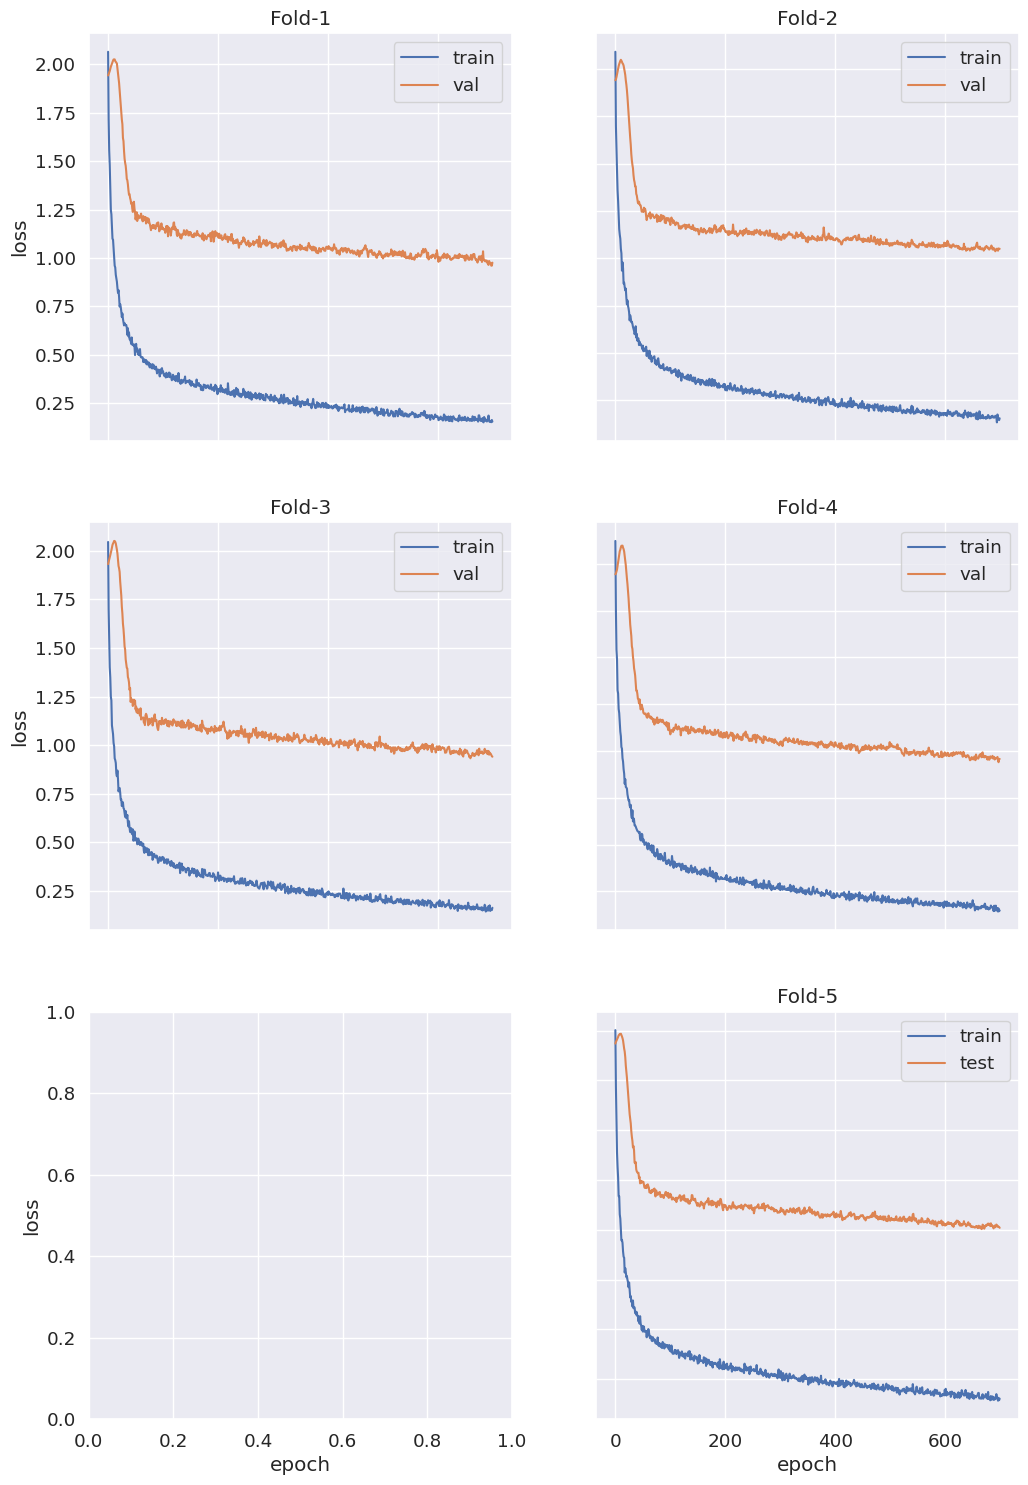

In [38]:
import matplotlib.pyplot as plt
import numpy as np

fig, axs = plt.subplots(3, 2,figsize=(12,18))
axs[0, 0].plot(hist[0].history['loss'])
axs[0, 0].plot(hist[0].history['val_loss'])
axs[0, 0].set_title('Fold-1')
axs[0, 0].legend(['train', 'val'], loc='upper right')

axs[0, 1].plot(hist[1].history['loss'])
axs[0, 1].plot(hist[1].history['val_loss'])
axs[0, 1].set_title('Fold-2')
axs[0, 1].legend(['train', 'val'], loc='upper right')

axs[1, 0].plot(hist[2].history['loss'])
axs[1, 0].plot(hist[2].history['val_loss'])
axs[1, 0].set_title('Fold-3')
axs[1, 0].legend(['train', 'val'], loc='upper right')

axs[1, 1].plot(hist[3].history['loss'])
axs[1, 1].plot(hist[3].history['val_loss'])
axs[1, 1].set_title('Fold-4')
axs[1, 1].legend(['train', 'val'], loc='upper right')

axs[2, 1].plot(hist[4].history['loss'])
axs[2, 1].plot(hist[4].history['val_loss'])
axs[2, 1].set_title('Fold-5')
axs[2, 1].legend(['train', 'test'], loc='upper right')

for ax in axs.flat:
    ax.set(xlabel='epoch', ylabel='loss')

# Hide x labels and tick labels for top plots and y ticks for right plots.
for ax in axs.flat:
    ax.label_outer()
fig.savefig('emovoBoth_4Folds_65.png')

In [1]:
import numpy as np
import keras
from keras.models import model_from_json
from sklearn.metrics import confusion_matrix

savedir = 'emovo_gender_both'
num_folds = 5 
opt = keras.optimizers.RMSprop(learning_rate=0.00001, decay=1e-6)

accuracies = []
conf_matrices = []

for i in range(num_folds):
    model_name = f"Model_{i}"

    with open(f"{savedir}/{model_name}.json", "r") as json_file:
        loaded_model = model_from_json(json_file.read())
    loaded_model.load_weights(f"{savedir}/{model_name}.h5")

    loaded_model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

    X_test = np.load(f"{savedir}/X_test_fold{i}.npy")
    y_test = np.load(f"{savedir}/y_test_fold{i}.npy")

    score = loaded_model.evaluate(X_test, y_test, verbose=0)
    acc = score[1] * 100
    accuracies.append(acc)

    y_pred = loaded_model.predict(X_test, verbose=0)
    y_pred_labels = np.argmax(y_pred, axis=1)
    y_true_labels = np.argmax(y_test, axis=1)

    cm = confusion_matrix(y_true_labels, y_pred_labels)
    conf_matrices.append(cm)

    print(f"Fold {i}: Accuracy = {acc:.2f}%")

# array: (num_folds, num_classes, num_classes)
conf_matrices = np.array(conf_matrices)

print("\nMean Accuracy: %.2f%%" % np.mean(accuracies))
print("SD Accuracy: %.2f" % np.std(accuracies))

n = num_folds
ci95 = 1.96 * (np.std(accuracies) / np.sqrt(n))
print("95%% CI: ± %.2f" % ci95)


2025-11-06 16:01:10.221561: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-06 16:01:10.254037: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-06 16:01:10.977007: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-

Fold 0: Accuracy = 69.49%
Fold 1: Accuracy = 69.49%
Fold 2: Accuracy = 75.42%
Fold 3: Accuracy = 76.07%
Fold 4: Accuracy = 70.09%

Mean Accuracy: 72.11%
SD Accuracy: 2.98
95% CI: ± 2.61


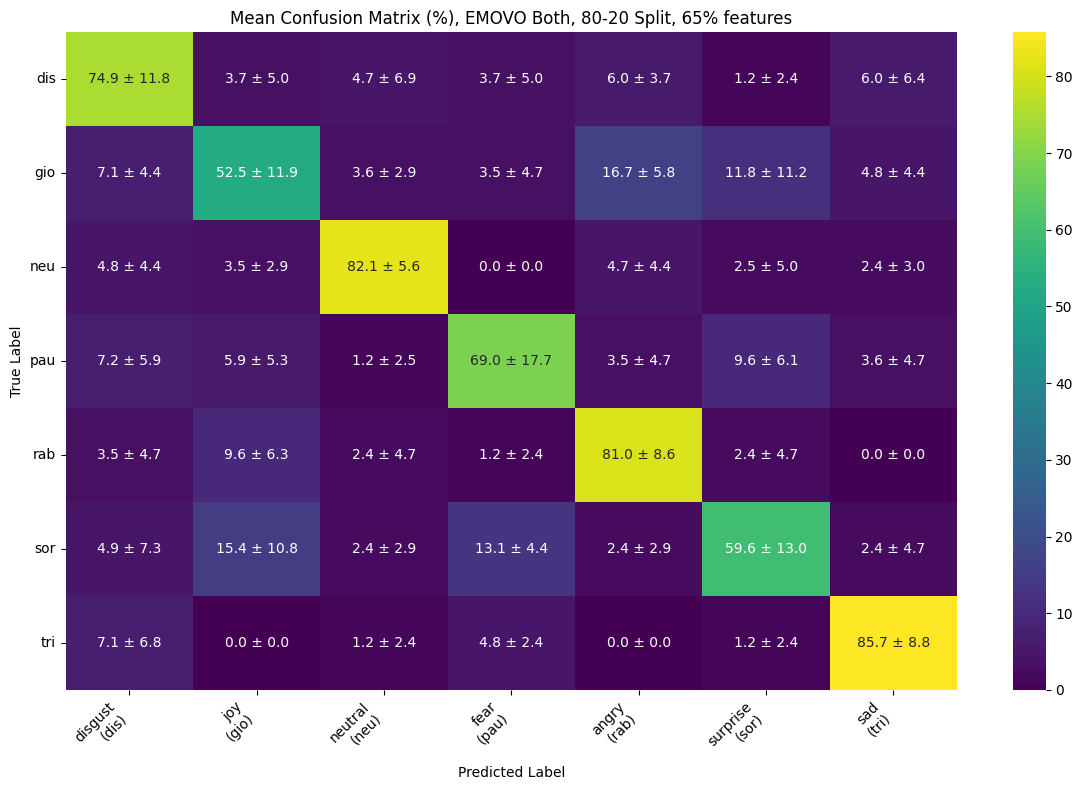

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

conf_matrices_percent = conf_matrices / conf_matrices.sum(axis=2, keepdims=True) * 100

np.save('cm_emovo_gender_both.npy', conf_matrices_percent)


mean_cm = np.mean(conf_matrices_percent, axis=0)
std_cm = np.std(conf_matrices_percent, axis=0)

labels = np.empty(mean_cm.shape, dtype=object)
for i in range(mean_cm.shape[0]):
    for j in range(mean_cm.shape[1]):
        labels[i, j] = f"{mean_cm[i, j]:.1f} ± {std_cm[i, j]:.1f}"

y_list = ['dis', 'gio', 'neu', 'pau', 'rab', 'sor', 'tri']
x_list = ['disgust\n(dis)', 'joy\n(gio)', 'neutral\n(neu)','fear\n(pau)', 'angry\n(rab)', 'surprise\n(sor)', 'sad\n(tri)']

# Plot
plt.figure(figsize=(12,8))
ax = sns.heatmap(mean_cm, annot=labels, fmt="", cmap="viridis", cbar=True)

ax.set_xticks(np.arange(len(x_list)) + 0.5)
ax.set_yticks(np.arange(len(y_list)) + 0.5)
ax.set_xticklabels(x_list, rotation=45, ha="right")
ax.set_yticklabels(y_list, rotation=0)

plt.title("Mean Confusion Matrix (%), EMOVO Both, 80-20 Split, 65% features")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()
